In [1]:
import torch
import numpy as np

def average_cosine(vectors):

    # Normalize each vector
    vectors_norm = vectors / vectors.norm(dim=1, keepdim=True)

    # Compute the cosine similarity matrix (dot product of normalized vectors)
    cosine_similarities = vectors_norm @ vectors_norm.T

    # Extract the upper triangle of the matrix, excluding the diagonal
    num_objects = vectors.shape[0]
    i, j = torch.triu_indices(num_objects, num_objects, offset=1)
    cosine_similarities_upper = cosine_similarities[i, j]
    # Calculate the average cosine similarity
    average_cosine = cosine_similarities_upper.mean().item()

    
    return average_cosine


def gen_W(num_objects, dim, target_cosine):
    # Define ranges
    sparsity_range = (0.002, 0.01)
    # Initialize the vectors tensor with random sparsity
    vectors = torch.zeros((num_objects, dim), dtype=torch.float)
    num_ones = torch.randint(int(sparsity_range[0] * dim), int(sparsity_range[1] * dim + 1), (num_objects,))
    for i in range(num_objects):
        ones_indices = torch.randperm(dim)[:num_ones[i]]
        vectors[i, ones_indices] = 1

    cos = average_cosine(vectors)
    if target_cosine==0 and cos!=0:
        vectors = torch.zeros((num_objects, dim), dtype=torch.float)
        num_ones = torch.randint(int(sparsity_range[0] * dim), int(sparsity_range[1] * dim + 1), (num_objects,))
        for i in range(num_objects):
            ones_indices = torch.randperm(dim)[:num_ones[i]]
            vectors[i, ones_indices] = 1

        cos = average_cosine(vectors)
        

    while(cos<target_cosine):
        # Randomly pick a pair of objects i and j
        indices = torch.randperm(num_objects)[:2]
        i, j = indices[0], indices[1]
        vi = vectors[i, :]
        vj = vectors[j, :]

        # Identify dimensions where only one of them has a 1 using XOR
        diff_indices = torch.nonzero(vi.int() ^ vj.int()).flatten()
        if len(diff_indices) > 0:
            # Randomly pick one such dimension
            dim_to_change = diff_indices[torch.randint(len(diff_indices), (1,)).item()]
        else:
            continue

        # Determine which vector has 0 at the chosen dimension
        if vi[dim_to_change] == 0:
            index_to_modify = i
        else:
            index_to_modify = j

        # Set the value of this object at the chosen dimension to 1
        vectors[index_to_modify, dim_to_change] = 1

        # Find a dimension in the same object that currently equals 1
        ones_indices = torch.nonzero(vectors[index_to_modify] == 1).flatten()
        ones_indices = ones_indices[ones_indices != dim_to_change]  # Exclude the modified dimension

        # Randomly pick one such dimension to set to 0
        dim_to_zero = ones_indices[torch.randint(len(ones_indices), (1,)).item()]
        vectors[index_to_modify, dim_to_zero] = 0

        # Compute the average cosine again
        cos = average_cosine(vectors)
#     print(cos)
    return vectors.T



In [8]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
from sklearn.utils import shuffle

# Define the number of objects and dimensions
num_objects = 5
input_dim = num_objects
context_dim = 2
hidden_dim = 1000
hidden_context_dim = 1000
output_dim = 100

# Ground truth ranking
ground_truth_ranking1 = [0,1,2,3,4]
ground_truth_ranking2 = [0,3,2,4,1]

# Create all possible pairs of objects
pairs1 = [(i, j) for i in range(num_objects) for j in range(num_objects) if i != j]
labels1 = [(1 if ground_truth_ranking1.index(i) < ground_truth_ranking1.index(j) else -1) for i, j in pairs1]
pairs2 = [(i, j) for i in range(num_objects) for j in range(num_objects) if i != j]
labels2 = [(1 if ground_truth_ranking2.index(i) < ground_truth_ranking2.index(j) else -1) for i, j in pairs2]

# One-hot encode the input
one_hot_vectors = torch.eye(num_objects)


cos=0
W = gen_W(num_objects, hidden_dim, cos)

# Initialize P (trainable)
P1 = torch.randn(output_dim, hidden_dim) * 0.0001
P2 = torch.randn(output_dim, hidden_dim) * 0.0001

# Learning rate
eta = 0.1

# Number of epochs
num_epochs = 10

# Define the error function
def error_function(v_i, v_j, label):
    error = torch.sign(torch.maximum((label * (v_i - v_j) +1), torch.tensor(0))*label)
    return error

# Track the mean of v for each object over epochs
mean_v_values1 = np.zeros((num_epochs*len(pairs1)+1, num_objects))
mean_v_values2 = np.zeros((num_epochs*len(pairs1)+1, num_objects))

for i in range(num_objects):
    s_i1 = W @ one_hot_vectors[i]
    v_i1 = P1 @ s_i1
    mean_v_values1[0, i] = v_i1.mean().item()

    s_i2 = W @ one_hot_vectors[i]
    v_i2 = P2 @ s_i2
    mean_v_values2[0, i] = v_i2.mean().item()
        
# Training loop
errors = []
iters=0
for epoch in tqdm(range(num_epochs), desc="Training Progress"):

    epoch_error = 0
    pairs2, labels2 = shuffle(pairs2, labels2)
    pairs1, labels1 = shuffle(pairs1, labels1)
    for (i1, j1), label1, (i2, j2), label2 in zip(pairs1, labels1, pairs2, labels2):
        #first linear order
        s_i1 = W @ one_hot_vectors[i1]
        s_j1 = W @ one_hot_vectors[j1]

        v_i1 = P1 @ s_i1
        v_j1 = P1 @ s_j1

        e1 = error_function(v_i1, v_j1, label1)
        epoch_error += e1.mean().item()
        P1 += eta * torch.outer(e1, (s_j1-s_i1))
        
        #second linear order
        s_i2 = W @ one_hot_vectors[i2]
        s_j2 = W @ one_hot_vectors[j2]


        v_i2 = P2 @ s_i2
        v_j2 = P2 @ s_j2

        e2 = error_function(v_i2, v_j2, label2)
        epoch_error += e2.mean().item()

        P2 += eta * torch.outer(e2, (s_j2-s_i2))
        # Compute the mean v values for each object
        for i in range(num_objects):
            s_i1 = W @ one_hot_vectors[i]
            v_i1 = P1 @ s_i1
            mean_v_values1[iters+1, i] = v_i1.mean().item()

            s_i2 = W @ one_hot_vectors[i]
            v_i2 = P2 @ s_i2
            mean_v_values2[iters+1, i] = v_i2.mean().item()
        iters+=1

    errors.append(epoch_error / (num_objects*2))



# Print the final results
summed_v_values1 = mean_v_values1[-1, :]
learned_ranking1 = sorted(range(num_objects), key=lambda i: summed_v_values1[i])

summed_v_values2 = mean_v_values2[-1, :]
learned_ranking2 = sorted(range(num_objects), key=lambda i: summed_v_values2[i])

print(f"Ground truth ranking: {ground_truth_ranking1}")
print(f"Learned ranking: {learned_ranking1}")
print(f"Mean v values: {summed_v_values1}")

print(f"Ground truth ranking: {ground_truth_ranking2}")
print(f"Learned ranking: {learned_ranking2}")
print(f"Mean v values: {summed_v_values2}")


Training Progress:   0%|          | 0/10 [00:00<?, ?it/s]

Ground truth ranking: [0, 1, 2, 3, 4]
Learned ranking: [0, 1, 2, 3, 4]
Mean v values: [-2.09996724 -1.00000918  0.40000424  1.60001433  3.59998202]
Ground truth ranking: [0, 3, 2, 4, 1]
Learned ranking: [0, 3, 2, 4, 1]
Mean v values: [-2.09997892  2.99999475  0.4000003  -0.80001205  1.80001616]


In [42]:
summed_v_values1_normalized = (summed_v_values1 - np.min(summed_v_values1)) / (np.max(summed_v_values1) - np.min(summed_v_values1)) * 2 + 1

summed_v_values2_normalized = (summed_v_values2 - np.min(summed_v_values2)) / (np.max(summed_v_values2) - np.min(summed_v_values2)) * 2 + 1


In [43]:
summed_v_values1_normalized

array([1.        , 1.38595363, 1.87719078, 2.2982507 , 3.        ])

In [44]:
import numpy as np
import matplotlib.pyplot as plt

# -------------------------
# Function Definitions
# -------------------------

def is_valid(pos, env_min=0, env_max=4):
    x, y = pos
    return env_min <= x <= env_max and env_min <= y <= env_max

def generate_grid_cells(n_cells=1000, arena_size=4, seed=None):
    if seed is not None:
        np.random.seed(seed)
    scales = np.random.uniform(0.02, 8, size=n_cells)
    phases = np.random.uniform(0, arena_size, size=(n_cells, 2))
    orientations = np.random.uniform(0, np.pi/3, size=n_cells)
    return scales, phases, orientations

def grid_activation(x, y, scales, phases, orientations):
    positions = np.array([x, y])
    activations = []
    angles = np.array([0, np.pi / 3, 2 * np.pi / 3])
    for scale, phase, orientation in zip(scales, phases, orientations):
        # Rotate and compute grating
        R = np.array([[np.cos(orientation), -np.sin(orientation)],
                      [np.sin(orientation),  np.cos(orientation)]])
        pos_rot = R @ (positions - phase)
        proj = pos_rot[0] * np.cos(angles) + pos_rot[1] * np.sin(angles)
        grating = np.sum(np.cos((4 * np.pi / (scale * np.sqrt(3))) * proj))
        activations.append((2/3) * grating)
    return np.array(activations)

def grid_activation_vectorized(X, Y, scales, phases, orientations):
    H, W = X.shape
    n_cells = len(scales)
    pos = np.stack([X.ravel(), Y.ravel()], axis=1)  # (H*W, 2)
    activations = np.zeros((H * W, n_cells))
    angles = np.array([0, np.pi / 3, 2 * np.pi / 3])

    for i in range(n_cells):
        scale = scales[i]
        phase = phases[i]
        orientation = orientations[i]
        c, s = np.cos(orientation), np.sin(orientation)
        R = np.array([[c, -s], [s, c]])
        rel_pos = pos - phase
        pos_rot = rel_pos @ R.T
        proj = np.outer(pos_rot[:, 0], np.cos(angles)) + np.outer(pos_rot[:, 1], np.sin(angles))
        grating = np.sum(np.cos((4 * np.pi / (scale * np.sqrt(3))) * proj), axis=1)
        activations[:, i] = (2/3) * grating

    return activations.reshape(H, W, n_cells)


# -------------------------
# Grid Cell Setup
# -------------------------

n_cells = 1000
env_min, env_max = 0, 4
scales, phases, orientations = generate_grid_cells(n_cells, env_max)

# -------------------------
# Plateau Events & Weights
# -------------------------

# grid_res = 50

# x_vals = np.linspace(env_min, env_max, grid_res)
# y_vals = np.linspace(env_min, env_max, grid_res)
# X, Y = np.meshgrid(x_vals, y_vals)

x_vals = summed_v_values1_normalized
y_vals = summed_v_values2_normalized

X = x_vals[None]
Y = y_vals[None]
grid_embeddings = grid_activation_vectorized(X, Y, scales, phases, orientations)


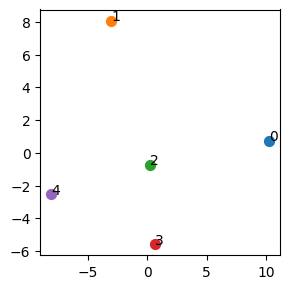

In [45]:
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt


threshold = np.percentile(scales,85)
large_indices = np.where(scales >= threshold)[0]

# Extract embeddings for only those cells and flatten
H, W, _ = grid_embeddings.shape
emb_large = grid_embeddings[:, :, large_indices].reshape(H * W, len(large_indices))

# PCA on filtered embeddings
pca_large = PCA(n_components=2)
pc_large = pca_large.fit_transform(emb_large)

# Plot
plt.figure(figsize=(3, 3), dpi=100)
for i in range(5):
    plt.scatter(pc_large[i, 0], pc_large[i, 1], s=50)
    plt.text(pc_large[i, 0], pc_large[i, 1],i)
# plt.title('PCA of Top 1%‑Scale Grid Cell Embeddings')
# plt.xlabel('PC1')
# plt.axis('off')
# plt.ylabel('PC2')
plt.tight_layout()
plt.show()


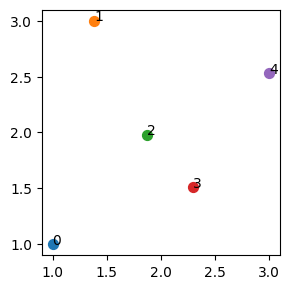

In [46]:
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt


threshold = np.percentile(scales,85)
large_indices = np.where(scales >= threshold)[0]

# Extract embeddings for only those cells and flatten
H, W, _ = grid_embeddings.shape
emb_large = grid_embeddings[:, :, large_indices].reshape(H * W, len(large_indices))

# PCA on filtered embeddings
pca_large = PCA(n_components=2)
pc_large = pca_large.fit_transform(emb_large)

# Plot
plt.figure(figsize=(3, 3), dpi=100)
for i in range(5):
    plt.scatter(x_vals[i], y_vals[i], s=50)
    plt.text(x_vals[i], y_vals[i],i)
# plt.title('PCA of Top 1%‑Scale Grid Cell Embeddings')
# plt.xlabel('PC1')
# plt.axis('off')
# plt.ylabel('PC2')
plt.tight_layout()
plt.show()


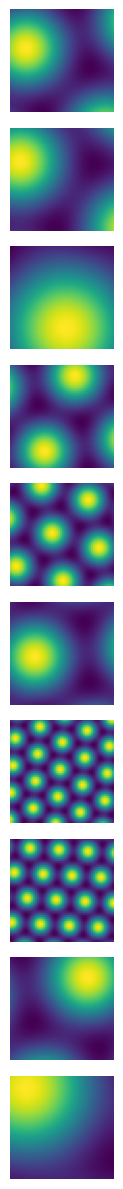

In [50]:
import numpy as np
import matplotlib.pyplot as plt

# -------------------------
# Function Definitions
# -------------------------

def is_valid(pos, env_min=0, env_max=4):
    x, y = pos
    return env_min <= x <= env_max and env_min <= y <= env_max

def generate_grid_cells(n_cells=1000, arena_size=4, seed=None):
    if seed is not None:
        np.random.seed(seed)
    scales = np.random.uniform(0.02, 8, size=n_cells)
    phases = np.random.uniform(0, arena_size, size=(n_cells, 2))
    orientations = np.random.uniform(0, np.pi/3, size=n_cells)
    return scales, phases, orientations

def grid_activation(x, y, scales, phases, orientations):
    positions = np.array([x, y])
    activations = []
    angles = np.array([0, np.pi / 3, 2 * np.pi / 3])
    for scale, phase, orientation in zip(scales, phases, orientations):
        # Rotate and compute grating
        R = np.array([[np.cos(orientation), -np.sin(orientation)],
                      [np.sin(orientation),  np.cos(orientation)]])
        pos_rot = R @ (positions - phase)
        proj = pos_rot[0] * np.cos(angles) + pos_rot[1] * np.sin(angles)
        grating = np.sum(np.cos((4 * np.pi / (scale * np.sqrt(3))) * proj))
        activations.append((2/3) * grating)
    return np.array(activations)

def grid_activation_vectorized(X, Y, scales, phases, orientations):
    H, W = X.shape
    n_cells = len(scales)
    pos = np.stack([X.ravel(), Y.ravel()], axis=1)  # (H*W, 2)
    activations = np.zeros((H * W, n_cells))
    angles = np.array([0, np.pi / 3, 2 * np.pi / 3])

    for i in range(n_cells):
        scale = scales[i]
        phase = phases[i]
        orientation = orientations[i]
        c, s = np.cos(orientation), np.sin(orientation)
        R = np.array([[c, -s], [s, c]])
        rel_pos = pos - phase
        pos_rot = rel_pos @ R.T
        proj = np.outer(pos_rot[:, 0], np.cos(angles)) + np.outer(pos_rot[:, 1], np.sin(angles))
        grating = np.sum(np.cos((4 * np.pi / (scale * np.sqrt(3))) * proj), axis=1)
        activations[:, i] = (2/3) * grating

    return activations.reshape(H, W, n_cells)

# -------------------------
# Grid Cell Setup
# -------------------------

n_cells = 10  # For example, let's visualize 3 grid cells
env_min, env_max = 0, 4
scales, phases, orientations = generate_grid_cells(n_cells, env_max)

# Create meshgrid for plotting
grid_res = 50
x_vals = np.linspace(env_min, env_max, grid_res)
y_vals = np.linspace(env_min, env_max, grid_res)
X, Y = np.meshgrid(x_vals, y_vals)

# Compute grid activations
grid_embeddings = grid_activation_vectorized(X, Y, scales, phases, orientations)

# -------------------------
# Visualization
# -------------------------
fig, axes = plt.subplots(n_cells, 1, figsize=(6, 12))

for i in range(n_cells):
    ax = axes[i]
    ax.imshow(grid_embeddings[:, :, i], extent=(env_min, env_max, env_min, env_max), origin='lower')
#     ax.set_title(f"Grid Cell {i+1}")
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
#     ax.grid(True)
    ax.axis('off')

plt.tight_layout()
plt.show()
